In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import re
from bs4 import BeautifulSoup
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
df.shape

(404290, 6)

In [4]:
new_df = df.sample(100000,random_state=2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


# Preprocessing ⚙️  

In [5]:
def preprocess(q):

    q = str(q).lower().strip()
    # Fix smart quotes
    q = q.replace("’", "'")

    #replace certain special characters with their meanings
    q = q.replace('%','percent')
    q = q.replace('$','dollar')
    q = q.replace('₹','rupee')
    q = q.replace('€','euro')
    q = q.replace('@','at')
    #In our data no mean of [math] so we remove it
    q = q.replace('[math]','')

    #Replace some numbers with equivalents
    q = q.replace(',000,000,000','b')
    q = q.replace(',000,000','m')
    q = q.replace(',000','k')
    q = re.sub(r'([0-9]+)000000000',r'\1b',q)
    q = re.sub(r'([0-9]+)000000',r'\1m',q)
    q = re.sub(r'([0-9]+)000',r'\1k',q)

    #Deconstructing the words
    # Source - https://stackoverflow.com/a/19794953
    # Posted by arturomp, modified by community. See post 'Timeline' for change history
    # Retrieved 2026-05-16, License - CC BY-SA 3.0
    
    contractions = { "ain't": "am not / are not / is not / has not / have not","aren't": "are not / am not","can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he had / he would",
    "he'd've": "he would have",
    "he'll": "he shall / he will",
    "he'll've": "he shall have / he will have",
    "he's": "he has / he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how has / how is / how does",
    "i'd": "i had / i would",
    "i'd've": "i would have",
    "i'll": "i shall / i will",
    "i'll've": "I shall have / I will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it had / it would",
    "it'd've": "it would have",
    "it'll": "it shall / it will",
    "it'll've": "it shall have / it will have",
    "it's": "it has / it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she had / she would",
    "she'd've": "she would have",
    "she'll": "she shall / she will",
    "she'll've": "she shall have / she will have",
    "she's": "she has / she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as / so is",
    "that'd": "that would / that had",
    "that'd've": "that would have",
    "that's": "that has / that is",
    "there'd": "there had / there would",
    "there'd've": "there would have",
    "there's": "there has / there is",
    "they'd": "they had / they would",
    "they'd've": "they would have",
    "they'll": "they shall / they will",
    "they'll've": "they shall have / they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we had / we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what shall / what will",
    "what'll've": "what shall have / what will have",
    "what're": "what are",
    "what's": "what has / what is",
    "what've": "what have",
    "when's": "when has / when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where has / where is",
    "where've": "where have",
    "who'll": "who shall / who will",
    "who'll've": "who shall have / who will have",
    "who's": "who has / who is",
    "who've": "who have",
    "why's": "why has / why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you had / you would",
    "you'd've": "you would have",
    "you'll": "you shall / you will",
    "you'll've": "you shall have / you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted =[]
    for word in q.split():
        # remove punctuation around words
        word = word.strip(".,!?;:")
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve",'have')
    q = q.replace("n't",'not')
    q = q.replace("'re",'are')
    q = q.replace("'ll",'will')

    #Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()

    #Remove Punctuation
    pattern = re.compile('\W')
    q = re.sub(pattern,' ',q).strip()

    return q

    

In [6]:
preprocess('Hey @John, I’m paying ₹5,000 and $2,000,000 for 50% of a company worth 3000000000! Why can’t I’ve gotten it? [math] Isn’t that’s crazy?')

'hey atjohn i am paying rupee5k and dollar2m for 50percent of a company worth 3b why cannot i have gotten it is not that has   that is crazy'

In [7]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


# Feature Engineering 🛠️

In [8]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [9]:
new_df['ques1_len'] = new_df['question1'].str.len()
new_df['ques2_len'] = new_df['question2'].str.len()

In [10]:
new_df['ques1_numWords'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['ques2_numWords'] = new_df['question2'].apply(lambda row: len(row.split(" ")))

In [11]:
def common_words(row):
    w1=set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(),row['question2'].split(" ")))
    return len(w1 & w2)

In [12]:
new_df['common_words'] = new_df.apply(common_words,axis=1)

In [13]:
def total_words(row):
    w1=set(map(lambda word: word.lower().strip(),row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(),row['question2'].split(" ")))
    return (len(w1)+len(w2))

In [14]:
new_df['total_words'] = new_df.apply(total_words,axis=1)


In [15]:
new_df['word_share']=round(new_df['common_words']/new_df['total_words'],2)


In [16]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,ques1_len,ques2_len,ques1_numWords,ques2_numWords,common_words,total_words,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7,22,0.32
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3,36,0.08
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0,32,0.00
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.23


# Advanced Features 🚀

##### token features

In [17]:
from nltk.corpus import stopwords

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001
    STOP_WORDS = stopwords.words("english")
    token_features = [0.0]*8

    #converting Sentence into tokens
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    #Get the non-stopwords in questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #Get the stopwords in questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    #Get the common non-stopwords from the question pair 
    common_words_count = len(q1_words.intersection(q2_words))

    #Get the common stopwords from the question pair 
    common_stop_count = len(q1_stops.intersection(q2_stops))

    #Get the common Tokens from the question pair 
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_words_count / (min(len(q1_words),len(q2_words)) + SAFE_DIV)
    token_features[1] = common_words_count / (max(len(q1_words),len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops),len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops),len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens),len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens),len(q2_tokens)) + SAFE_DIV)

    #last word of both question is same or not 
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    #first word of the both question is same or not 
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

    

In [18]:
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"] = list(map(lambda x: x[0], token_features))
new_df["cwc_max"] = list(map(lambda x: x[1], token_features))
new_df["csc_min"] = list(map(lambda x: x[2], token_features))
new_df["csc_max"] = list(map(lambda x: x[3], token_features))
new_df["ctc_min"] = list(map(lambda x: x[4], token_features))
new_df["ctc_max"] = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"] = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [19]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,ques1_len,ques2_len,ques1_numWords,ques2_numWords,...,total_words,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874989,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,22,0.32,0.666644,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,36,0.08,0.000000,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,32,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.23,0.749981,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0


In [20]:
import sys
!{sys.executable} -m pip install distance


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [21]:
import distance

def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0] * 3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute Length Features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_features

In [22]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [23]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,ques1_len,ques2_len,ques1_numWords,ques2_numWords,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0,3.0,13.5,0.229167
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0,6.0,23.0,0.048544
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.051724
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0,4.0,7.0,0.542857


In [24]:
import sys
!{sys.executable} -m pip install fuzzywuzzy


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [25]:
import sys
!{sys.executable} -m pip install python-Levenshtein


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [26]:
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    #fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1,q2)

    #fuzz_partial_ratio 
    fuzzy_features[1] = fuzz.partial_ratio(q1,q2)

    #fuzz_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1,q2)

    #fuzz_token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1,q2)

    return fuzzy_features

In [27]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [28]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,ques1_len,ques2_len,ques1_numWords,ques2_numWords,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,0.466664,1.0,1.0,3.0,13.5,0.229167,69,66,67,74
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,0.115384,0.0,0.0,6.0,23.0,0.048544,42,41,39,46
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,0.000000,0.0,0.0,17.0,21.5,0.051724,37,49,38,40
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333330,1.0,0.0,4.0,7.0,0.542857,60,71,48,69


## Function help for new datas

In [29]:
def test_common_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return len(w1 & w2)

In [30]:
def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return (len(w1) + len(w2))

In [31]:
def test_fetch_token_features(q1,q2):
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [32]:
def test_fetch_length_features(q1,q2):
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [33]:
def test_fetch_fuzzy_features(q1,q2):
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [34]:
def query_point_creator(q1, q2):

    input_query = []

    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))

    input_query.append(test_common_words(q1, q2))
    input_query.append(test_total_words(q1, q2))
    input_query.append(
        round(test_common_words(q1, q2) / test_total_words(q1, q2), 2)
    )

    # fetch token features
    token_features = test_fetch_token_features(q1, q2)
    input_query.extend(token_features)

    # fetch length based features
    length_features = test_fetch_length_features(q1, q2)
    input_query.extend(length_features)

    # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1, q2)
    input_query.extend(fuzzy_features)
    
    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()
    
    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()
    
    return np.hstack(
        (np.array(input_query).reshape(1,22), q1_bow, q2_bow)
    )
    
        

#### EDA

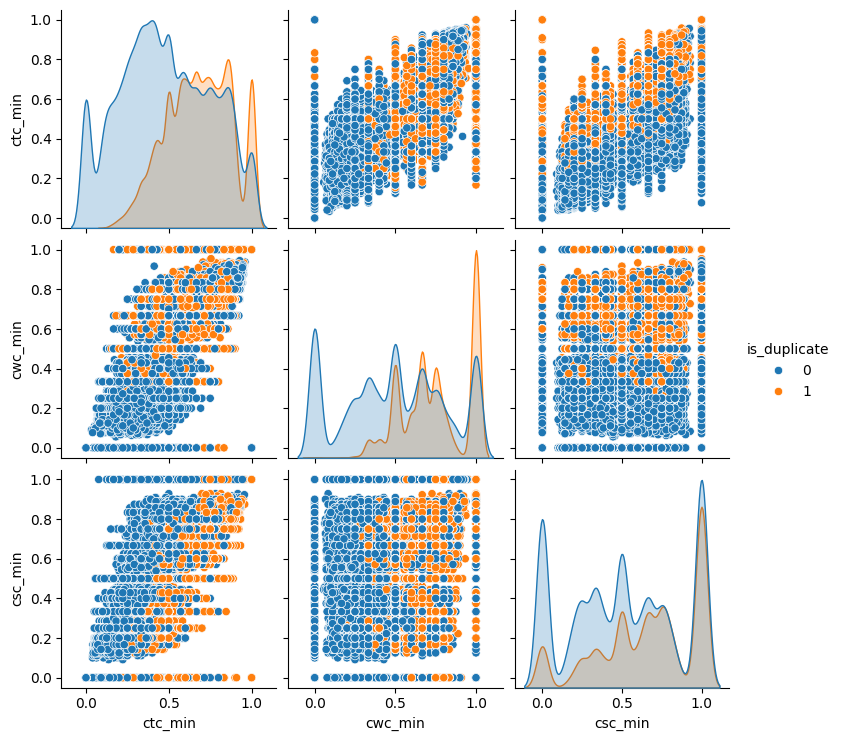

In [35]:
sns.pairplot(new_df[['ctc_min','cwc_min','csc_min','is_duplicate']],hue='is_duplicate')

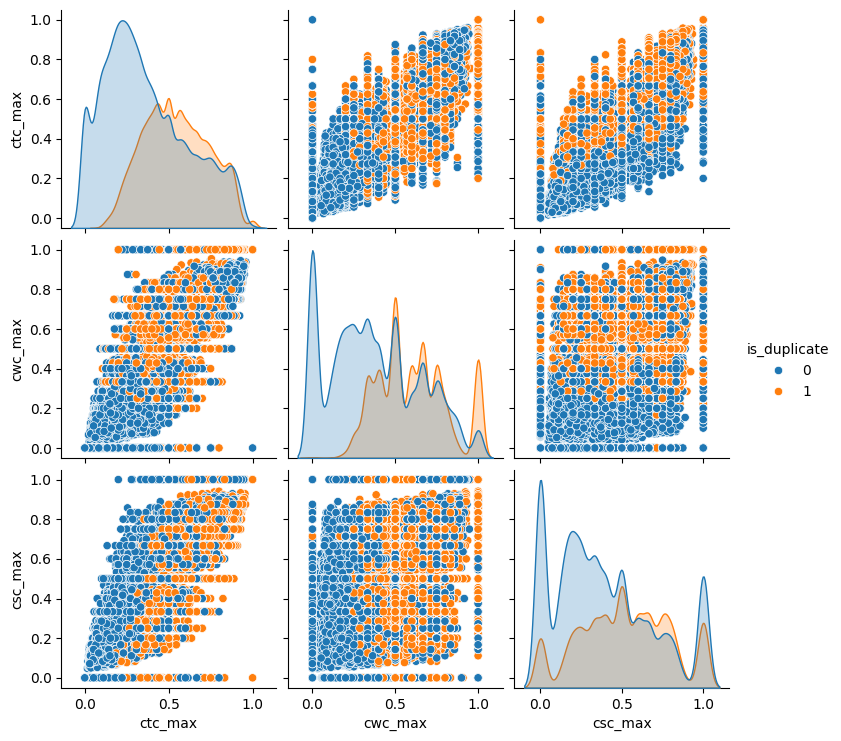

In [36]:
sns.pairplot(new_df[['ctc_max','cwc_max','csc_max','is_duplicate']],hue='is_duplicate')

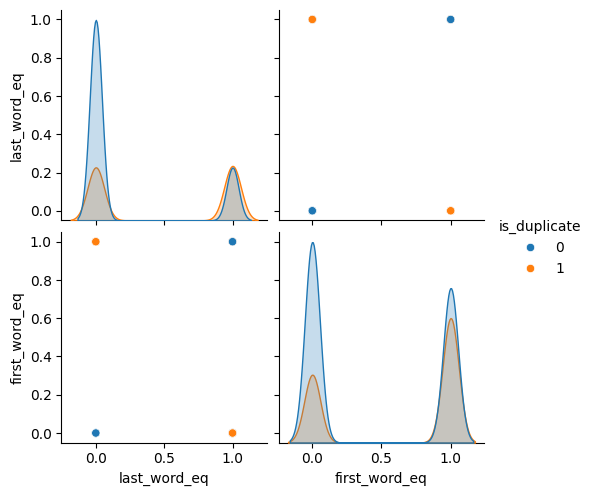

In [37]:
sns.pairplot(new_df[['last_word_eq','first_word_eq','is_duplicate']],hue='is_duplicate')

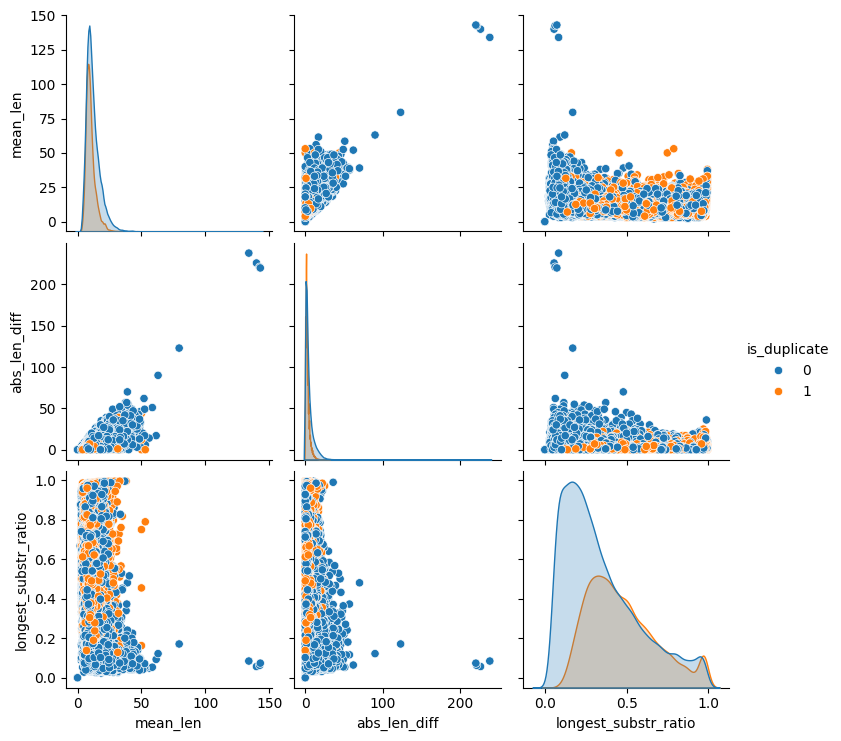

In [38]:
sns.pairplot(new_df[['mean_len','abs_len_diff','longest_substr_ratio','is_duplicate']],hue='is_duplicate')

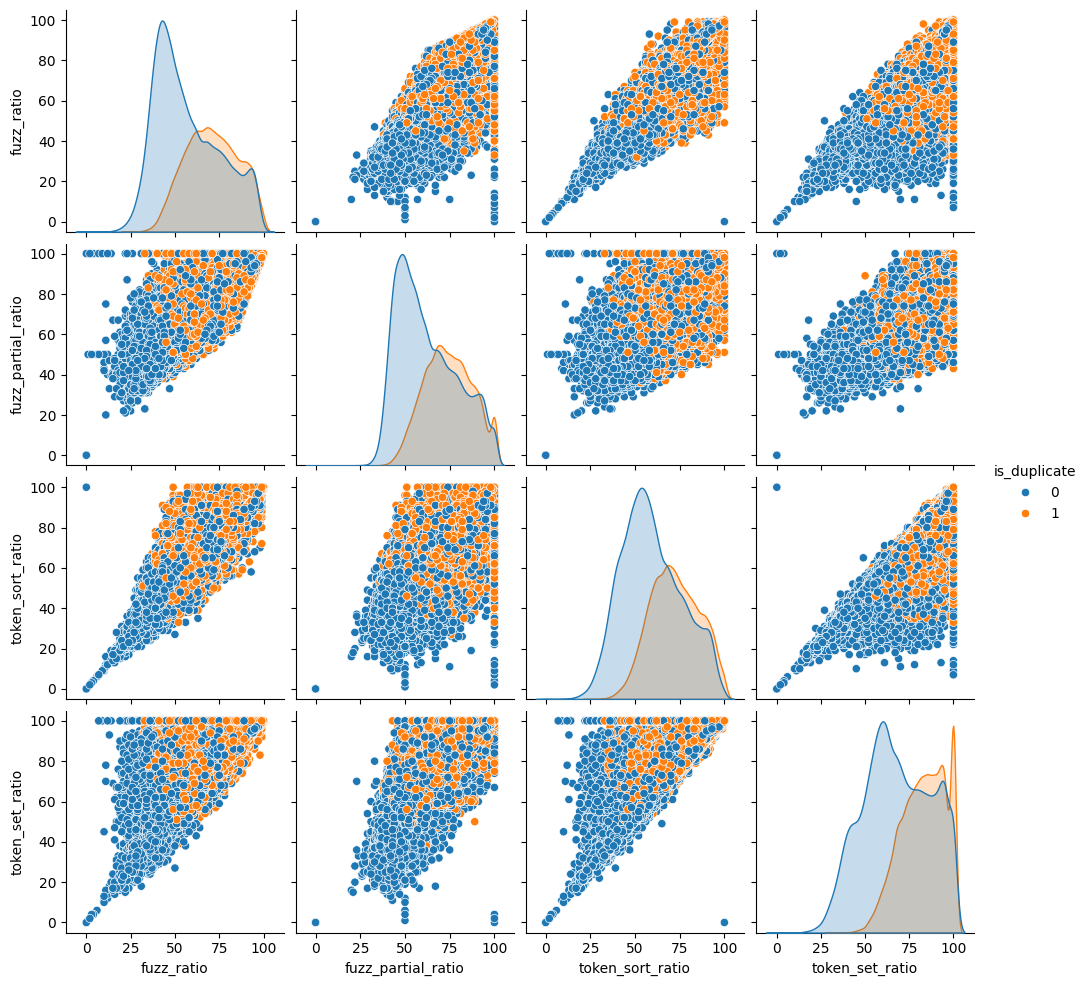

In [39]:
sns.pairplot(new_df[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio','is_duplicate']],hue='is_duplicate')

In [40]:
from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(
    new_df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max',
            'ctc_min', 'ctc_max', 'last_word_eq',
            'first_word_eq', 'abs_len_diff',
            'mean_len', 'longest_substr_ratio',
            'fuzz_ratio', 'fuzz_partial_ratio',
            'token_sort_ratio', 'token_set_ratio']]
)

y = new_df['is_duplicate'].values

In [41]:
# from sklearn.manifold import TSNE

# tsne2d = TSNE(
#     n_components=2,
#     init='random',   # pca
#     random_state=101,
#     method='barnes_hut',
#     max_iter=1000,
#     verbose=2,
#     angle=0.5
# ).fit_transform(X)

In [42]:
# import plotly.graph_objs as go
# import plotly.offline as py

# # Create 2D scatter plot
# trace = go.Scatter(
#     x=tsne2d[:,0],
#     y=tsne2d[:,1],
#     mode='markers',

#     marker=dict(
#         size=8,
#         color=y,
#         colorscale='Portland',
#         colorbar=dict(title='duplicate'),
#         opacity=0.7
#     )
# )

# data = [trace]

# layout = go.Layout(
#     title='2D embedding with engineered features',
#     width=800,
#     height=600
# )

# fig = go.Figure(data=data, layout=layout)

# py.iplot(fig)

In [43]:
# tsne2d = TSNE(
#     n_components=3,
#     init='random',   # pca
#     random_state=101,
#     method='barnes_hut',
#     max_iter=1000,
#     verbose=2,
#     angle=0.5
# ).fit_transform(X)

In [44]:
# import plotly.graph_objs as go
# import plotly.offline as py

# # Create 3D scatter plot
# trace1 = go.Scatter3d(
#     x=tsne2d[:,0],           #tsne2d , i give this name in transform to 3d so i use it , if you want then change in above code 2d to 3d and also change here 3d okk
#     y=tsne2d[:,1],
#     z=tsne2d[:,2],
#     mode='markers',

#     marker=dict(
#         size=5,
#         sizemode='diameter',
#         color=y,
#         colorscale='Portland',
#         colorbar=dict(title='duplicate'),
#         line=dict(color='rgb(255,255,255)', width=1),
#         opacity=0.75
#     )
# )

# data = [trace1]

# layout = go.Layout(
#     height=800,
#     width=800,
#     title='3D embedding with engineered features'
# )

# fig = go.Figure(data=data, layout=layout)

# py.iplot(fig)

In [45]:
ques_df = new_df[["question1","question2"]]
ques_df.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...
327711,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [46]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(100000, 23)


,is_duplicate,ques1_len,ques2_len,ques1_numWords,ques2_numWords,common_words,total_words,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,0,47,55,12,15,7,22,0.32,0.666644,0.499988,...,0.466664,1.0,1.0,3.0,13.5,0.229167,69,66,67,74
327711,0,102,118,26,20,3,36,0.08,0.000000,0.000000,...,0.115384,0.0,0.0,6.0,23.0,0.048544,42,41,39,46
367788,0,57,143,13,30,0,32,0.00,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.051724,37,49,38,40
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0.333330,1.0,0.0,4.0,7.0,0.542857,60,71,48,69


# Apply Bag Of Word

In [47]:
# from sklearn.feature_extraction.text import CountVectorizer
# questions = list(ques_df['question1']) + list(ques_df['question2'])
# cv = CountVectorizer(max_features=5000)
# q1_arr,q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [48]:
# temp_df1 = pd.DataFrame(q1_arr,index=ques_df.index)
# temp_df2 = pd.DataFrame(q2_arr,index=ques_df.index)
# temp_df = pd.concat([temp_df1,temp_df2],axis=1)
# temp_df.shape

In [49]:
# final_df1 = pd.concat([final_df,temp_df],axis=1)
# print(final_df1.shape)                                
# final_df1.head()

# Apply TF IDF

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
# questions = list(ques_df['question1']) + list(ques_df['question2'])
# tfidf = TfidfVectorizer(max_features=5000)
# q1_arr,q2_arr = np.vsplit(tfidf.fit_transform(questions).toarray(),2)

In [87]:
# temp_df1 = pd.DataFrame(q1_arr,index=ques_df.index)
# temp_df2 = pd.DataFrame(q2_arr,index=ques_df.index)
# temp_df = pd.concat([temp_df1,temp_df2],axis=1)
# temp_df.shape

In [88]:
# final_df = pd.concat([final_df,temp_df],axis=1)
# print(final_df.shape)                                
# final_df.head()

In [89]:
# final_df.columns = [f'feature_{i}' for i in range(final_df.shape[1])]

In [90]:
# final_df.head()    #feature_0 is for is_duplicate column

# Word2Vec

In [91]:
from gensim.models import Word2Vec
import numpy as np

# Convert questions into token lists
questions = list(ques_df['question1']) + list(ques_df['question2'])

sentences = [q.split() for q in questions]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # size of vector
    window=5,
    min_count=1,
    workers=4
)

# Function to convert a sentence into a single vector
def sentence_vector(sentence):

    words = sentence.split()

    vectors = []

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    # If sentence empty
    if len(vectors)==0:
        return np.zeros(100)

    return np.mean(vectors,axis=0)


# Create vectors for question1
q1_arr = np.array(
    ques_df['question1'].apply(sentence_vector).tolist()
)

# Create vectors for question2
q2_arr = np.array(
    ques_df['question2'].apply(sentence_vector).tolist()
)

print(q1_arr.shape)
print(q2_arr.shape)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(100000, 100)
(100000, 100)


In [94]:
import pandas as pd

# Combine everything
final_df = np.hstack((final_df, q1_arr, q2_arr))

# Convert back to DataFrame
final_df = pd.DataFrame(final_df)

# Give unique names
final_df.columns = [f'feature_{i}' for i in range(final_df.shape[1])]

print(final_df.shape)

(100000, 10623)


In [95]:
final_df.head()    #feature_0 for is_duplicate

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_10613,feature_10614,feature_10615,feature_10616,feature_10617,feature_10618,feature_10619,feature_10620,feature_10621,feature_10622
0,1.0,75.0,76.0,13.0,13.0,12.0,26.0,0.46,0.874989,0.874989,...,-0.183413,0.329213,0.056416,0.236550,-0.100638,-0.174731,-0.144453,-0.959315,-0.182023,0.695506
1,0.0,47.0,55.0,12.0,15.0,7.0,22.0,0.32,0.666644,0.499988,...,-0.883590,0.253784,-0.444459,0.457531,-0.358788,-0.457889,-0.101492,-0.828893,-0.779366,0.257967
2,0.0,102.0,118.0,26.0,20.0,3.0,36.0,0.08,0.000000,0.000000,...,-0.394291,0.061463,-0.003053,0.384982,-0.286473,-0.135625,-0.726274,-0.998486,-0.225198,0.366959
3,0.0,57.0,143.0,13.0,30.0,0.0,32.0,0.00,0.000000,0.000000,...,-0.614884,-0.431461,0.224801,0.323678,-0.823273,0.233917,-0.954207,-0.959161,-1.761942,0.364993
4,0.0,34.0,49.0,5.0,9.0,3.0,13.0,0.23,0.749981,0.599988,...,0.123672,-0.297934,0.430127,-0.441478,0.375853,0.609429,-0.604300,-0.493475,-0.589485,0.289963


# 👀 Accuracy

In [83]:
# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:],final_df.iloc[:,0],test_size=0.2,random_state=42)

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    final_df.iloc[:,1:],

    final_df.iloc[:,0],

    test_size=0.2,

    random_state=42

)

### RandomForest

In [98]:
from sklearn.metrics import accuracy_score

In [97]:
from sklearn.metrics import confusion_matrix

In [57]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# rf = RandomForestClassifier(n_jobs=-1,random_state=42)
# rf.fit(X_train,y_train)
# y_pred = rf.predict(X_test)
# accuracy_score(y_test,y_pred)       #0.8048

In [58]:
#Random Forest Confusion Metrix
# confusion_matrix(y_test,y_pred)    # Random forest is perform better no due to more Accuracy just observe the mistakes in Confusion

### RF after apply Tf Idf

In [59]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# rf1 = RandomForestClassifier(n_estimators=1000,n_jobs=-1,random_state=42)
# rf1.fit(X_train,y_train)
     

In [60]:
# y_pred_tf = rf1.predict(X_test)
# accuracy_score(y_test,y_pred_tf)     #0.8033

In [61]:
# #Random Forest Confusion Metrix
# confusion_matrix(y_test,y_pred_tf)    # Random forest is perform better no due to more Accuracy just observe the mistakes in Confusion

### XGBoost

In [62]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score

# xgb = XGBClassifier(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=6,
#     random_state=42,
#     n_jobs=-1
# )

# xgb.fit(X_train, y_train)

# y_pred1 = xgb.predict(X_test)

# accuracy_score(y_test, y_pred1)      #0.7811

In [63]:
#XGBoost Confusion metrics
# confusion_matrix(y_test,y_pred1)

### XGBoost apply After Tf Idf

In [64]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score

# xgb1 = XGBClassifier(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=6,
#     random_state=42,
#     n_jobs=-1
# )

# xgb1.fit(X_train, y_train)

# y_pred1_tf = xgb1.predict(X_test)

# accuracy_score(y_test, y_pred1_tf)   #0.78395

In [65]:
#XGBoost Confusion metrics
# confusion_matrix(y_test,y_pred1_tf)

### lightgbm

In [66]:
%pip install lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [99]:
from lightgbm import LGBMClassifier

In [68]:
# lgbm = LGBMClassifier(n_estimators=1000,learning_rate=0.03,max_depth=8,num_leaves=50,min_child_samples=20,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=0.1)

# lgbm.fit(X_train, y_train)


In [69]:
# y_pred2 = lgbm.predict(X_test)
# accuracy_score(y_test, y_pred2)     #0.8048

In [70]:
# confusion_matrix(y_test,y_pred2)

### LightGBM after Tf Idf

In [100]:
# import lightgbm as lgb
# lgbm1 = LGBMClassifier(n_estimators=3000,learning_rate=0.03,max_depth=8,num_leaves=50,min_child_samples=20,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=0.1,random_state=42)

# lgbm1.fit(X_train, y_train,eval_set=[(X_test, y_test)],eval_metric='binary_logloss',callbacks=[lgb.early_stopping(100),lgb.log_evaluation(100)

#     ])
# y_pred2_tf = lgbm1.predict(X_test)
# accuracy_score(y_test, y_pred2_tf)   #0.81715

In [101]:
# confusion_matrix(y_test,y_pred2_tf)

## LightGBM after Word2Vec

In [102]:
import lightgbm as lgb
lgbm1 = LGBMClassifier(n_estimators=3000,learning_rate=0.03,max_depth=8,num_leaves=50,min_child_samples=20,subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=0.1,random_state=42)

lgbm1.fit(X_train, y_train,eval_set=[(X_test, y_test)],eval_metric='binary_logloss',callbacks=[lgb.early_stopping(100),lgb.log_evaluation(100)

    ])
y_pred2_tf = lgbm1.predict(X_test)
accuracy_score(y_test, y_pred2_tf)

[LightGBM] [Info] Number of positive: 29276, number of negative: 50724
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.714245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 401321
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 7560
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365950 -> initscore=-0.549631
[LightGBM] [Info] Start training from score -0.549631
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.430258
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [103]:
accuracy_score(y_test, y_pred2_tf)

0.82045

### CatBoost

In [ ]:
%pip install catboost

In [75]:
from catboost import CatBoostClassifier

In [ ]:
# cb = CatBoostClassifier(
#     iterations=1000,       
#     learning_rate=0.03,   
#     depth=8,               
#     loss_function='Logloss',
#     eval_metric='Accuracy',
#     l2_leaf_reg=3,         
#     random_strength=1,     
#     bagging_temperature=1, 
#     border_count=128,      
#     random_seed=42,
#     verbose=100
# )
# cb.fit(X_train,y_train)
# y_pred3 = cb.predict(X_test)
# accuracy_score(y_test,y_pred3)  #0.8029

In [ ]:
# confusion_matrix(y_test,y_pred3)

### CatBoost after Tf Idf

In [76]:
# cb1 = CatBoostClassifier(
#     iterations=700,       
#     learning_rate=0.03,   
#     depth=8,               
#     loss_function='Logloss',
#     eval_metric='Accuracy',
#     l2_leaf_reg=3,         
#     random_strength=1,     
#     bagging_temperature=1, 
#     border_count=128,      
#     random_seed=42,
#     verbose=100
# )
# cb1.fit(X_train,y_train,eval_set=(X_test, y_test),early_stopping_rounds=100,verbose=100)   #this early_stopping and verbose show the Accuracy also and also shown exact which iteration you get best Accuracy
# y_pred3_tf = cb1.predict(X_test)
# accuracy_score(y_test,y_pred3_tf)  #0.81505


CatBoostError: catboost/libs/data/features_layout.cpp:124: All feature names should be different, but '0' used more than once.

## SVM after Tf Idf

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [ ]:
# svm1 = LinearSVC(C=1.5,max_iter=5000,class_weight='balanced',random_state=42)
# svm1.fit(X_train,y_train)
# y_pred_svm_tf = svm1.predict(X_test)
# accuracy_score(y_test,y_pred_svm_tf)   #0.77905

## Stacking 

In [ ]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier

# estimators=[('lgbm',LGBMClassifier(n_estimators=1000,learning_rate=0.04,verbosity=1)),('cat',CatBoostClassifier(iterations=1000,verbose=100)),('rf',RandomForestClassifier(n_estimators=500,n_jobs=-1,verbose=1)),('xgb',XGBClassifier(n_estimators=1000))]
# stack=StackingClassifier(estimators=estimators,final_estimator=LogisticRegression(max_iter=5000),cv=3,n_jobs=-1)
# stack.fit(X_train,y_train)
# y_pred_s=stack.predict(X_test)
# accuracy_score(y_test,y_pred_s)

In [ ]:
# from sklearn.ensemble import StackingClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier
# from sklearn.ensemble import RandomForestClassifier

# estimators = [
#     ('rf', RandomForestClassifier(n_estimators=300)),
#     ('cb', CatBoostClassifier(iterations=1000,learning_rate=0.03,depth=8)),
#     ('lgbm', LGBMClassifieri(n_estimators=1000,learning_rate=0.03,max_depth=8))
# ]
# model1 = StackingClassifieri(estimatorsma=estimators,final_estimator=LogisticRegression())

# model1.fit(X_train,y_train)

In [ ]:
# y_pred5 = model1.predict(X_test)
# accuracy_score(y_test,y_pred5)

# Intern Test For New Data 🧪

In [ ]:
# q1 = "How can I learn Python programming quickly?"
# q2 = "What is the fastest way to learn Python programming?"   # Similar to q1

# q3 = "What are the health benefits of drinking green tea?"
# q4 = "How do I reset my WiFi router password?"   # Not similar to q3

In [ ]:
# query_point_creator(q1,q2)

In [ ]:
# rf.predict(query_point_creator(q3,q4))  #Intern test Pass

In [ ]:
# cv

## Export the trained Files 📦 

In [ ]:
# import pickle

# pickle.dump(lgbm1,open('model2.pkl','wb')) #model1 for BOW  but model2.pkl for Tf IDF with lightgbm
# pickle.dump(tfidf,open('tfidf1.pkl','wb')) #cv1.pkl is wrong but tfidf1 is correct use in fast api